Step 1: Read the revised dataset

In [1]:
import pandas as pd

df = pd.read_csv("combined_reviews.csv")
df.head()



,review_year,review_month,review_day,airline,review_text,seat_comfort,staff_service,food_beverage,inflight_entertainment,ground_service,wifi_connectivity,value_for_money,recommended,verification,overall_rating,cleaned_review_text
0,2024,8,15,british_airways,"Before my flight, I was forced by the ground s...",NaN,NaN,NaN,1.0,NaN,NaN,1.0,no,not verified,NaN,flight forced ground staff check new expensive...
1,2024,8,12,british_airways,British Airways at its best. Outstanding servi...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,no,verified,NaN,british airways best outstanding service fligh...
2,2024,8,12,british_airways,An excellent flight! Despite this being a 4.5 ...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,no,verified,NaN,excellent flight despite hour flight aircraft_...
3,2024,8,11,british_airways,I recently traveled with British Airways and h...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,no,verified,NaN,recently traveled british airways mixed experi...
4,2024,8,9,british_airways,My family and I were booked to leave London fo...,NaN,NaN,NaN,1.0,NaN,NaN,1.0,no,verified,NaN,family booked leave london hong kong date_valu...


Step 2: Text Analysis

This step focuses on discovering insights to understand further about the dataset. 

2.1 - Word Cloud


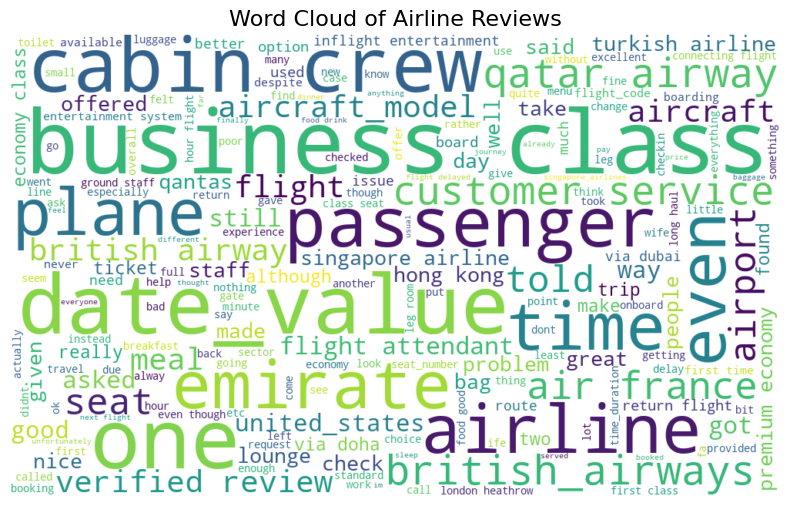

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cleaned_review_text'])
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Airline Reviews", fontsize=16)
plt.show()


2.2 - Word Count Frequencies

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


         Word  Frequency
0      flight      37681
1     service      17509
2        food      12643
3        time      12053
4        good      11820
5        seat      11570
6        crew      10882
7   datevalue      10002
8       class       9977
9       seats       9713
10      staff       9622
11      cabin       9328
12   business       8774
13        one       8747
14      would       7891
15   emirates       7183
16   airlines       7156
17    economy       7150
18    flights       7078
19    airline       7004


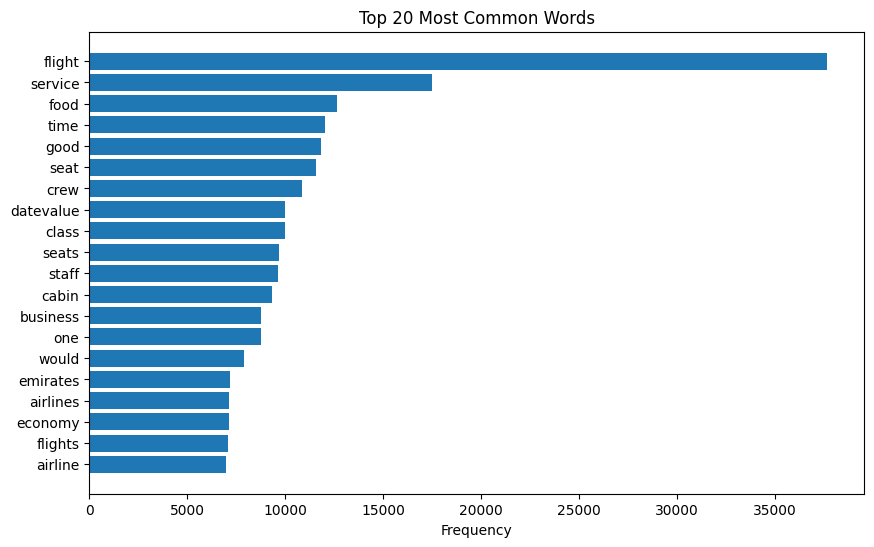

In [3]:
from collections import Counter
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Combine all reviews into one big string
text = " ".join(df['cleaned_review_text'].dropna()).lower()

# Remove punctuation and numbers
text = re.sub(r'[^a-z\s]', '', text)

# Split into word count frequencies
words = text.split()
word_counts = Counter(words)

# Download stopwords (run once)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Filter them out
filtered_words = [word for word in words if word not in stop_words]

# Count again
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

print(common_words)


# Plot
top_words = word_counts.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10,6))
plt.barh(words, counts)
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.show()





2.3 - Basic Descriptive Statistics

In [4]:
# Make sure df has the review_text column
df['cleaned_review_text'] = df['cleaned_review_text'].fillna('')  # replace NaN with empty string

# Word count per review
df['word_count'] = df['cleaned_review_text'].apply(lambda x: len(x.split()))

# Character count (excluding spaces)
df['char_count'] = df['cleaned_review_text'].apply(lambda x: len(re.sub(r'\s+', '', x)))

# Average word length (avoid division by zero)
df['avg_word_length'] = df.apply(
    lambda row: row['char_count'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1
)

# Sentence count (rough estimate using punctuation)
df['sentence_count'] = df['cleaned_review_text'].apply(lambda x: len(re.split(r'[.!?]+', x)) - 1)

# Summary statistics
text_stats = {
    'Average Word Count': df['word_count'].mean(),
    'Average Sentence Count': df['sentence_count'].mean(),
    'Average Word Length': df['avg_word_length'].mean(),
    'Max Word Count': df['word_count'].max(),
    'Min Word Count': df['word_count'].min(),
}

for k, v in text_stats.items():
    print(f"{k}: {v:.2f}")


Average Word Count: 76.55
Average Sentence Count: 0.00
Average Word Length: 6.22
Max Word Count: 641.00
Min Word Count: 8.00


2.4 - N Gram Analysis

🔹 Top 20 Most Common Bigrams:
                        Bigram  Frequency
69718           business class       6324
71525               cabin crew       4281
383930           qatar airways       2994
124854        customer service       2652
9885                air france       2609
65730          british airways       2257
524724         verified review       2182
445826      singapore airlines       1934
370901         premium economy       1599
509064        turkish airlines       1592
237911               hong kong       1580
159567           economy class       1501
193753       flight attendants       1370
252671  inflight entertainment       1351
408485           return flight       1209
224863            ground staff       1120
240634             hour flight       1092
110806       connecting flight       1046
287465         london heathrow       1003
277853                leg room        893


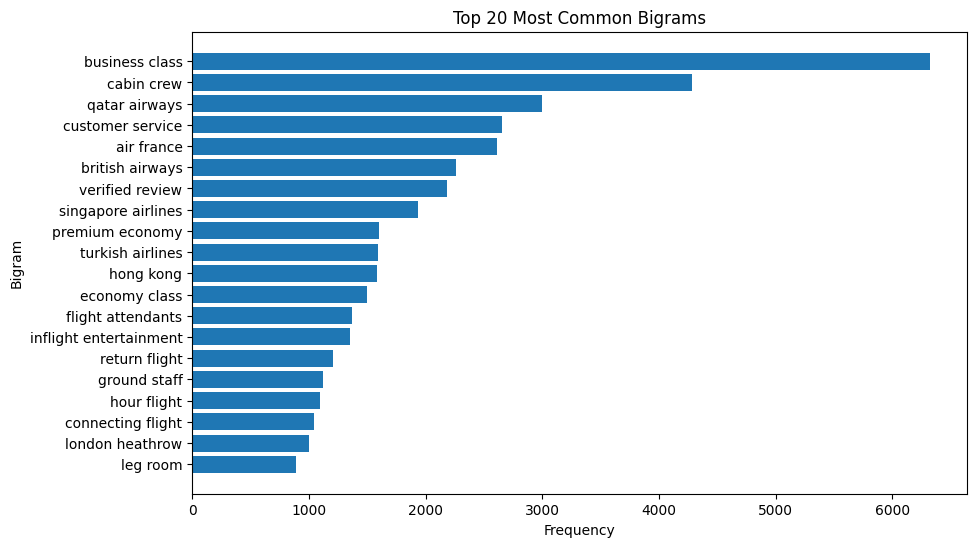


🔹 Top 20 Most Common Trigrams:
                          Trigram  Frequency
127270       business class seats        356
127265        business class seat        276
126971      business class lounge        257
127108  business class passengers        244
131590        cabin crew friendly        234
953049     verified review london        227
269709         doha qatar airways        221
539028           long haul flight        215
952970       verified review flew        207
602234          new york new_york        202
584455   missed connecting flight        173
126493       business class cabin        170
355044       flight delayed hours        166
127166     business class product        161
539029          long haul flights        160
352443          flight cabin crew        149
378958             fly air france        149
382984       flying qatar airways        145
798737         service cabin crew        139
449739                ho chi minh        135


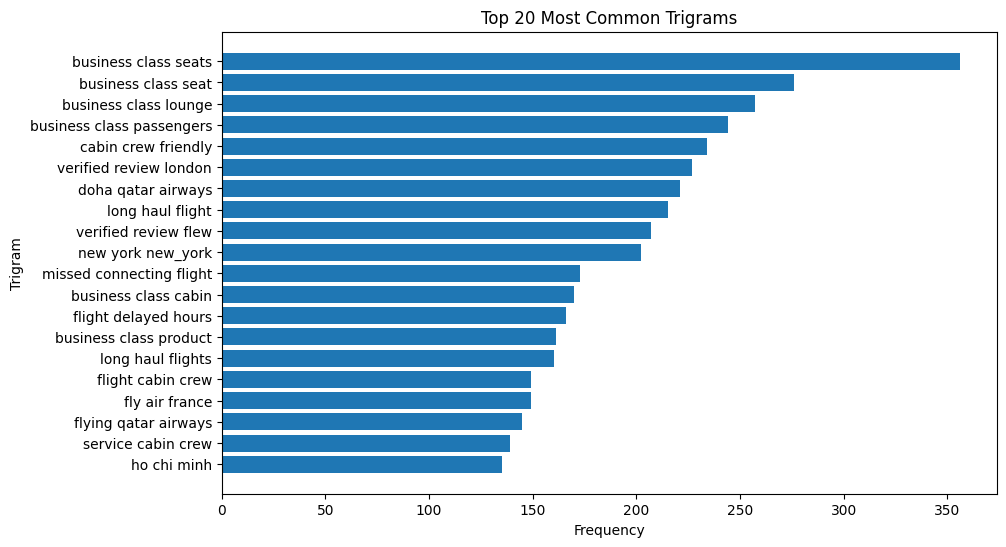

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt


# Bigrams (2-word phrases)
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), stop_words='english')
X2 = vectorizer_bigram.fit_transform(df['cleaned_review_text'].dropna())

# Frequencies of each bigram word
bigrams = pd.DataFrame(
    zip(vectorizer_bigram.get_feature_names_out(), X2.sum(axis=0).tolist()[0]),
    columns=['Bigram', 'Frequency']
).sort_values(by='Frequency', ascending=False).head(20)

print("🔹 Top 20 Most Common Bigrams:")
print(bigrams)

# Bigram Plots
plt.figure(figsize=(10,6))
plt.barh(bigrams['Bigram'], bigrams['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.show()


# Trigrams (3-word phrases) 
vectorizer_trigram = CountVectorizer(ngram_range=(3,3), stop_words='english')
X3 = vectorizer_trigram.fit_transform(df['cleaned_review_text'].dropna())

# Frequencies of each trigram word
trigrams = pd.DataFrame(
    zip(vectorizer_trigram.get_feature_names_out(), X3.sum(axis=0).tolist()[0]),
    columns=['Trigram', 'Frequency']
).sort_values(by='Frequency', ascending=False).head(20)

print("\n🔹 Top 20 Most Common Trigrams:")
print(trigrams)

# Tigram Plots
plt.figure(figsize=(10,6))
plt.barh(trigrams['Trigram'], trigrams['Frequency'])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Common Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.show()